## DEM Download

**Script to get DEMs for an area of interest**

*Prepared by Curtis Smith curtis.smith@stantec.com*

*updated to handle user defined data 11/9/2021*

In [2]:
import os, sys, copy, shutil, subprocess
import pathlib as pl

In [3]:
import geopandas as gpd
import sys, copy, shutil, subprocess
import pathlib as pl
import fiona
import pyproj
import descartes
import json
import numpy as np
import sys
from IPython.display import clear_output
import matplotlib.pyplot as plt
%matplotlib inline
# %load_ext autoreload
# %autoreload 2

In [4]:
home = pl.Path(os.getcwd())

In [5]:
sys.path.append(str(pl.Path(home.parent)))
from src.grass_functions import*
from src.process_inputs import*

C:\Program Files\GRASS GIS 7.8\etc\python\grass\script\db.py:147: SyntaxWarning: invalid escape sequence '\g'
  :param str args:  see \gmod{db.select} arguments
C:\Program Files\GRASS GIS 7.8\etc\python\grass\script\setup.py:30: SyntaxWarning: invalid escape sequence '\O'
  grass7bin = r'C:\OSGeo4W\bin\grass78.bat'
C:\Program Files\GRASS GIS 7.8\etc\python\grass\pygrass\modules\interface\parameter.py:141: SyntaxWarning: invalid escape sequence '\d'
  isrange = re.match("(?P<min>-*\d+.*\d*)*-(?P<max>\d+.*\d*)*",
C:\Program Files\GRASS GIS 7.8\etc\python\grass\pygrass\modules\interface\module.py:233: SyntaxWarning: invalid escape sequence '\_'
  To run the Module objects in parallel the run\_ and finish\_ options


### Set parameters

In [6]:
#set project variables
Project_Area = 'haw_river'
projection = '2264' #set to None if you want to use the DEM's original projection
res = '1m'

## Set variables analysis
source = 'wbd' #wbd or user-defined
data_scale = 'HUC12' #other options HUC12, HUC10, HUC8 OR the field name of the source data to be split <-- case sensitive
select_data = '030300020407' #     # Value within the filter_field used for data selection
to_headwaters = False #False if only interested in local huc area
input_shp_name = None #None or must be populated populated with a shapefile polygons if data_scale != HUCXX
buffer = 2000
auto_delete = False

In [7]:
if data_scale.find('HUC') >= 0:
    huc_level = re.findall("[0-9]+",data_scale)[0]
    if huc_level == str(len(select_data)):
        huc_digys = huc_level
    else:
        huc_digys = huc_level
        select_data = select_data[:int(huc_digys)]

In [8]:
parent_dir = pl.Path(os.getcwd()).parent/'data'

## Paths:
vector_parent_dir = parent_dir/'Vectors'
current_dir = pl.Path(os.getcwd())
vector_dir = parent_dir/'Vectors'/Project_Area
if not os.path.exists(vector_dir):
    os.makedirs(vector_dir)
raster_dir = parent_dir/'Rasters'/Project_Area
if not os.path.exists(raster_dir):
    os.makedirs(raster_dir)
git_data_repo = current_dir/'data_repository'

if input_shp_name:
    input_shp = vector_dir/input_shp_name
outputs_dir =parent_dir/'Rasters'/Project_Area/'dem'

### Get area of interest

In [9]:
#prep work
assert source in ['wbd','user-defined']
if source == 'wbd':
    wbd = nhd_download(select_data,vector_dir)

    #read in HUC12s vector file from NHD
    local_huc4 = gpd.read_file(vector_dir/wbd, layer='WBDHU{}'.format(huc_digys))

    #reformat fields to handle disparate USGS data formats
    local_huc4 = lower_pd_cols(local_huc4.copy())
    if to_headwaters:
        ## function to get most downstream HUC12 if HUC10 or HUC8 is entered
        select_data = get_downstream_huc12(select_data,local_huc4)

        #get all upstream HUC12s
        local_huc12 = local_huc4.loc[local_huc4['huc12'] == select_data]
        upstream_list = get_upstream_extent_usgs(select_data) #selected huc12
        aoi = local_huc4.loc[local_huc4['huc12'].isin(upstream_list) == True]
    else:
        aoi = local_huc4.loc[local_huc4['huc{}'.format(huc_digys)] == select_data]
        local_huc12 = None
else:
    shp = gpd.read_file(input_shp)
    shp = shp.rename({'HUC10_mod':'perim'},axis=1)
    aoi = shp.loc[shp[data_scale] == select_data]
    local_huc12 = None
#save to vector for later analysis
huc_path = vector_dir/'{0}_{1}_aoi.geojson'.format(Project_Area,select_data)

#fix topological errors
###TODO only apply if shape is polygon
aoi['geometry'] = aoi.buffer(0) 
if projection in esri_crs:
    aoi = aoi.to_crs(pyproj.CRS.from_authority("esri", int(projection)))
    aoi.to_file(str(huc_path),driver="GeoJSON")
else:
    aoi.to_crs(epsg=projection)
    aoi.to_file(str(huc_path),driver="GeoJSON")

opening: https://prd-tnm.s3.amazonaws.com/StagedProducts/Hydrography/NHDPlusHR/Beta/GDB/NHDPLUS_H_0303_HU4_GDB.zip
saving to: c:\git\dem_prep\data\Vectors\haw_river\NHDPLUS_H_0303_HU4_GDB.gdb


[2026-05-12 08:14:11,682] [INFO] [raw] : Created 1 records


In [10]:
aoi = gpd.read_file(str(huc_path),driver="GeoJSON")

c:\Users\Curtis.Smith\AppData\Local\miniforge3\envs\geoenv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


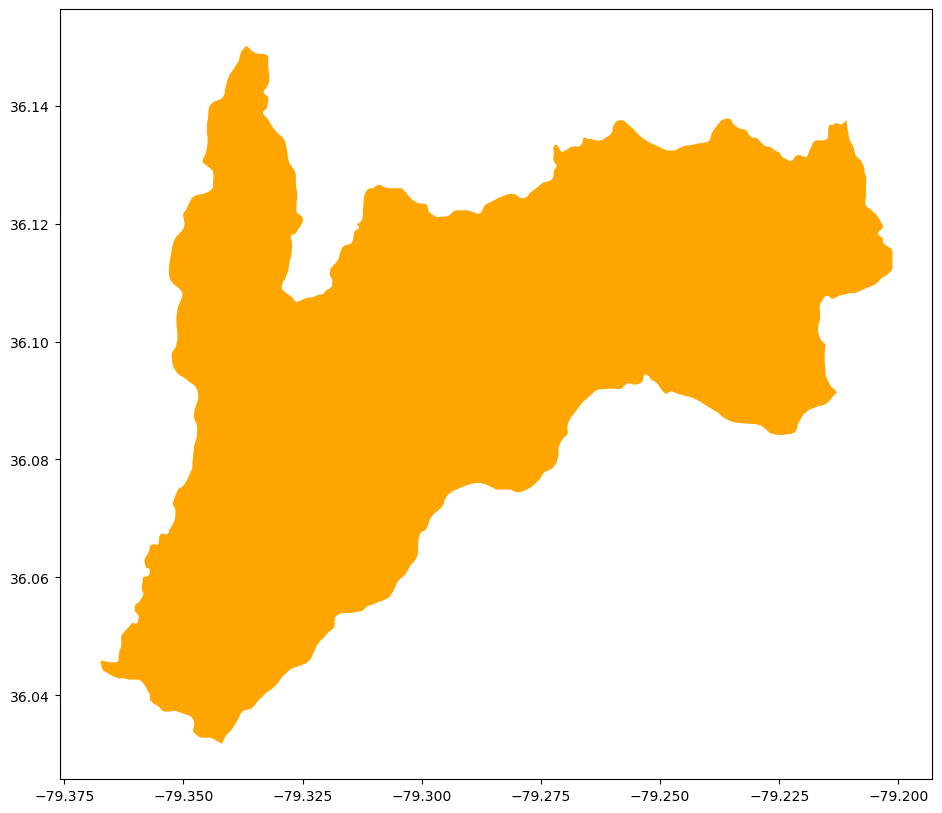

In [11]:
#plot
fix1, ax1 = plt.subplots(figsize=(30,10))
aoi.plot(ax = ax1, color = 'orange', edgecolor = 'white')
plt.show()

### Gather best DEM

In [12]:
##intersect with web service to get dem links
gdf_dem, aoi_coverage_buffer = tnm_coverage(aoi,desired_resolution=res, buffer = buffer, minimum_coverage = 0.95) 

1m not available. Checking next best resolution
Best available DEM is 3m
coverage is 100.0 percent


In [13]:
#reduce to only where buffer intersects tiles
gdf_dem_reduced = gpd.sjoin(gdf_dem,gpd.GeoDataFrame(geometry=gpd.GeoSeries(aoi_coverage_buffer)),how='inner', predicate='intersects')

In [14]:
gdf_dem_reduced['dl_link'].to_list()

['https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/19/IMG/ned19_n36x25_w079x50_nc_statewide_2003.zip',
 'https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/19/IMG/ned19_n36x25_w079x25_nc_statewide_2003.zip']

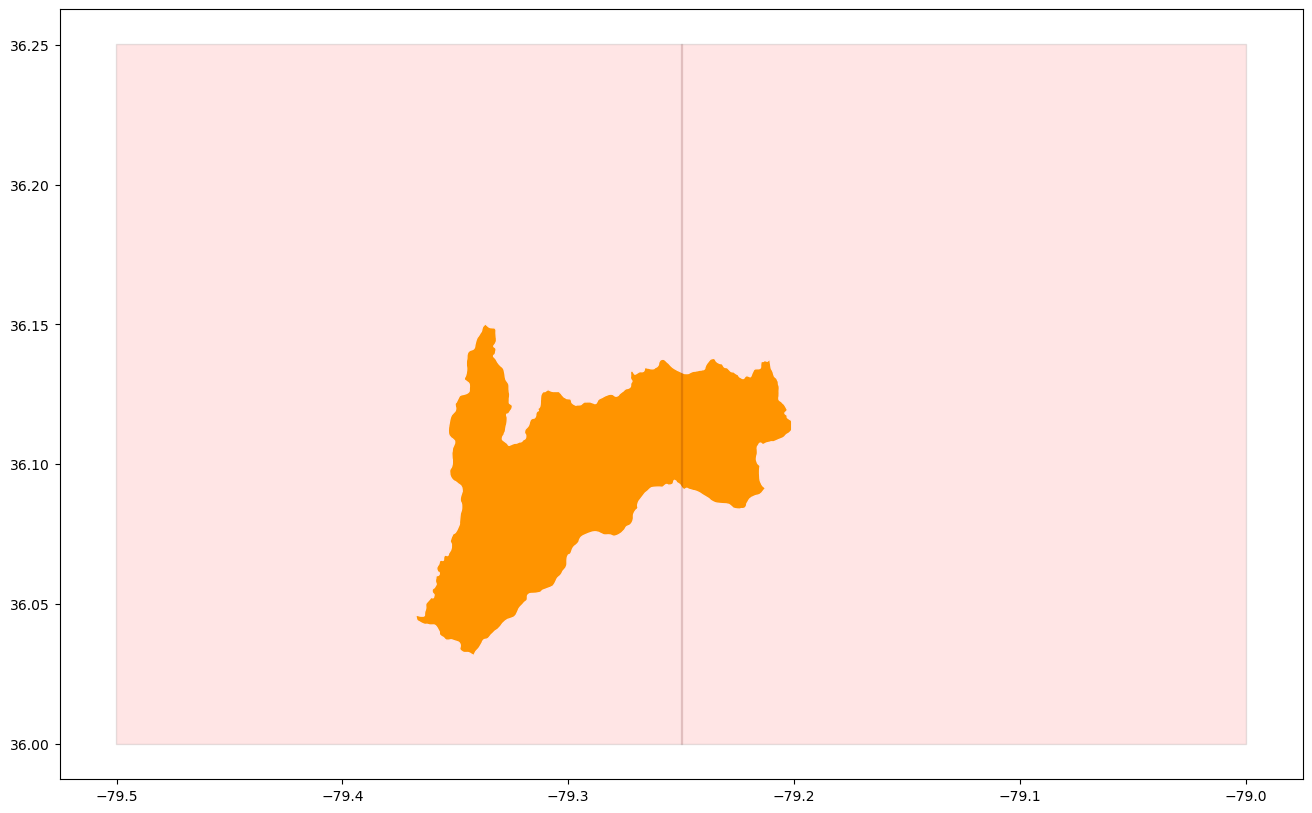

In [15]:
#plot
fix1, ax1 = plt.subplots(figsize=(30,10))
aoi.to_crs(gdf_dem.crs).plot(ax = ax1, color = 'orange', edgecolor = 'white')
gdf_dem_reduced.plot(ax = ax1,color = 'red',edgecolor = 'black', alpha=0.1)
plt.show()

### Export metadata

In [16]:
meta = gdf_dem_reduced[['title','publicationDate','vendorMetaUrl','geometry']].to_file(vector_dir/f'DEM_metadata_{select_data}.shp')

C:\Users\Curtis.Smith\AppData\Local\Temp\ipykernel_14436\174493256.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  meta = gdf_dem_reduced[['title','publicationDate','vendorMetaUrl','geometry']].to_file(vector_dir/f'DEM_metadata_{select_data}.shp')
c:\Users\Curtis.Smith\AppData\Local\miniforge3\envs\geoenv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'publicationDate' to 'publicatio'
  ogr_write(
c:\Users\Curtis.Smith\AppData\Local\miniforge3\envs\geoenv\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'vendorMetaUrl' to 'vendorMeta'
  ogr_write(
[2026-05-12 08:14:26,444] [INFO] [raw] : Created 2 records


### Download DEM Links 

In [23]:
meta

In [17]:
#dem prefered format
DEM_format = 'TIFF' #other options are TIFF, IMG, ArcGrid

In [18]:
dem_links = []
dem_folder = []
raw_links = gdf_dem_reduced['urls'].to_list()
pub_date = gdf_dem_reduced['publicationDate'].to_list()

In [19]:
for entry, date in zip(raw_links,pub_date):
    if DEM_format in entry.keys(): ##updated to handle IMG, TIFF and ZIP files
        dem_links.append(entry[DEM_format])
        dem_folder.append(date)
    if 'varies' in entry.keys():
        dem_links.append(entry['varies'])
        dem_folder.append(date)

In [20]:
#curtis to update code to choose IMG if TIFF not available and then unzip the IMG files as part of the dem download function
##download
dems = dem_download(dem_links,outputs_dir,dem_folder,docker=pem)

### Confirm RASTER coverage

In [21]:
raster_paths = []
raster_paths_all = glob.glob(str(raster_dir)+f'/dem/**/*.{DEM_format[:3].lower()}',recursive=True)
for rp in raster_paths_all:
    if pl.Path(rp).parts[-1] in dems:
        raster_paths.append(rp)

In [22]:
out_vrt = process_dems(raster_paths, select_data, projection, overwrite=True)

IndexError: list index out of range

[2026-04-22 10:39:20,925] [WARNING] [features] : CPLE_AppDefined in DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.
[2026-04-22 10:39:20,942] [INFO] [raw] : Created 1 records


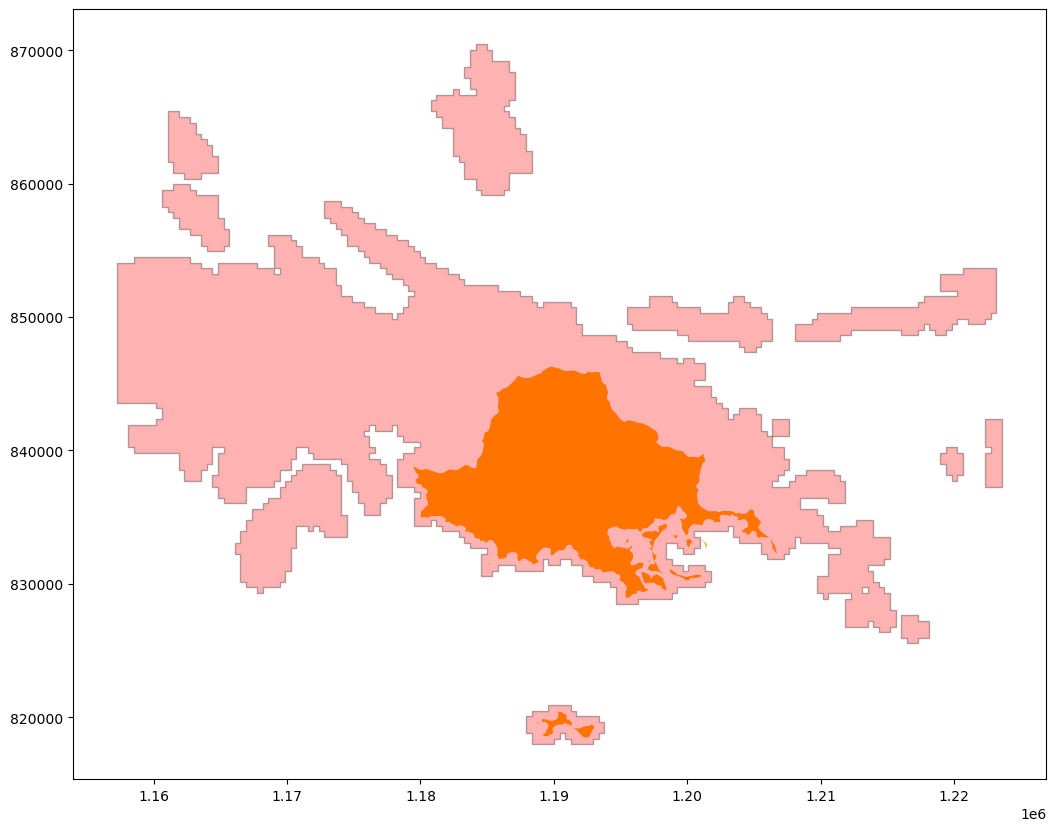

[2026-04-22 10:39:21,053] [INFO] [process_inputs] : coverage is 99.9 percent


In [ ]:
covered = check_dem_coverage(out_vrt, huc_path, minimum_coverage = 0.8)

In [23]:
if not covered and auto_delete:
    shutil.rmtree(out_vrt.parent)
    print('DEM does not fully cover area of interest, specify next best DEM and rerun')

## End